In [1]:


import pandas as pd
import numpy as np
from tqdm import tqdm

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

import tensorflow
print("TF Version:", tensorflow.__version__)
#tensorflow.config.set_visible_devices([], 'GPU') # Hide the GPU from TF

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split

# Load CSVs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Load a sample image
sample_id = train_df.iloc[0]["Id"]
sample_label = train_df.iloc[0]["Category"]
img_path = Path(f"train/train/{sample_label}/{sample_id}.png")

      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
Train size: 17000, Test size: 3000


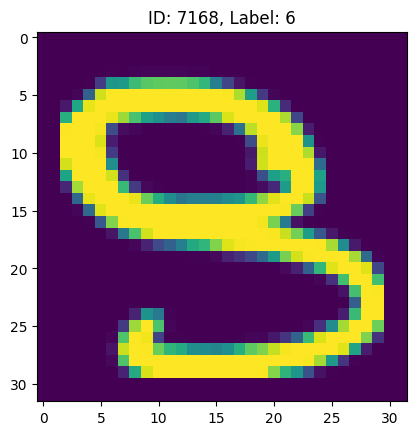

In [26]:
# view original image

img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id}, Label: {sample_label}")
plt.show()

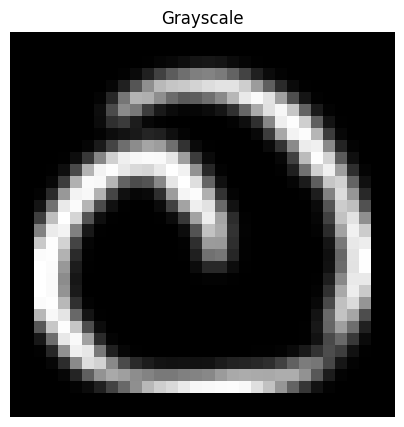

In [27]:
# convert to grayscale
# function from lab 3
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Pick one image from class 0

img_path = "train/train/0/103265.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_images([gray], ["Grayscale"])

In [ ]:
# train images to grayscale
# import pandas as pd
# import numpy as np

# train_df = pd.read_csv("train.csv")

# images = []
# labels = []

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     images.append(gray)
#     labels.append(label)

# images = np.array(images)
# labels = np.array(labels)

# print(f"Loaded {len(images)} images, shape: {images.shape}")

In [2]:
# # save grayscale images locally
'''
from pathlib import Path

output_dir = Path(os.path.join(BASE_DIR,"train_gray"))
output_dir.mkdir(exist_ok=True)

for _, row in train_df.iterrows():
    img_id = row["Id"]
    label = row["Category"]
    path = os.path.join(BASE_DIR, "train/train", f"{label}/{img_id}.png")

    img = cv2.imread(path)
    if img is None:
        # Instead of crashing, we print a warning and skip
        print(f" Warning: Could not find image at {path}")
        continue
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(str(output_dir / f"{img_id}.png"), gray)

print("Done saving grayscale images")'''

train_df = pd.read_csv("train.csv")

X_mini = []
y_mini = []

print("Starting Mini-Load...")
# Only try 500 images to see if it works
for i in range(500):
    row = train_df.iloc[i]
    img_path = f"train_gray/{row['Id']}.png"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        X_mini.append(img)
        y_mini.append(row['Category'])

X_mini = np.array(X_mini).astype('float32') / 255.0
X_mini = np.expand_dims(X_mini, -1)
print(f"Mini-load done! Shape: {X_mini.shape}")

Starting Mini-Load...
Mini-load done! Shape: (500, 32, 32, 1)


In [24]:

num_samples = len(train_df)
X = np.zeros((num_samples, 32, 32, 1), dtype='float32')
y = train_df["Category"].values

print(f"Allocated memory for {num_samples} images...")

for i, (idx, row) in enumerate(tqdm(train_df.iterrows(), total=num_samples)):
    img_path = f"train_gray/{row['Id']}.png"
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        # Normalize, keep (32, 32, 1) shape
        X[i] = np.expand_dims(img.astype('float32') / 255.0, axis=-1)
    else:
        print(f"Warning: Image {img_path} not found.")


# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=75, stratify=y)

print(f"Final Training Shape: {X_train.shape}") # (n images, 32, 32, 1)


Allocated memory for 17000 images...


100%|███████████████████████████████████| 17000/17000 [00:10<00:00, 1694.70it/s]

Final Training Shape: (12750, 32, 32, 1)


In [28]:
def basis_lenet(input_shape):

  model = keras.models.Sequential()

  model.add(layers.Input(shape=input_shape))
  model.add(layers.Rescaling(1./255))

  model.add(keras.layers.Conv2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh'))
  model.add(layers.BatchNormalization())
  model.add(keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

  model.add(keras.layers.Conv2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh'))
  model.add(layers.BatchNormalization())
  model.add(keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))
    

  # Flatten the output so that we can connect it with the fully connected layer
  model.add(keras.layers.Flatten())
    
  # fully connected layers
  model.add(keras.layers.Dense(units=120, activation='tanh'))
  model.add(layers.BatchNormalization())
  model.add(keras.layers.Dense(units=84, activation='tanh'))
  model.add(layers.BatchNormalization())
    
  # output 
  model.add(keras.layers.Dense(units=10, activation='softmax'))

  return model

def get_model(input_shape):
    model = keras.models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Rescaling(1./255))

    # More filters (32 instead of 6) and 'relu' instead of 'tanh'
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    
    model.add(layers.Dense(10, activation='softmax'))
    return model

Epoch 1/100
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8820 - loss: 0.3754
Epoch 1: val_accuracy improved from -inf to 0.19835, saving model to best_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8823 - loss: 0.3745 - val_accuracy: 0.1984 - val_loss: 2.9212
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9831 - loss: 0.0592
Epoch 2: val_accuracy improved from 0.19835 to 0.98824, saving model to best_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9831 - loss: 0.0592 - val_accuracy: 0.9882 - val_loss: 0.0590
Epoch 3/100
396/399 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9911 - loss: 0.0329
Epoch 3: val_accuracy did not improve from 0.98824
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9911 - loss: 0.0330 - val_accuracy: 0.9835 - val_loss: 0.0560
Epoch 4/100
396/399 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9919 - loss: 0.0284
Epoch 4: val_accuracy improved from 0.98824 to 0.99129, saving model

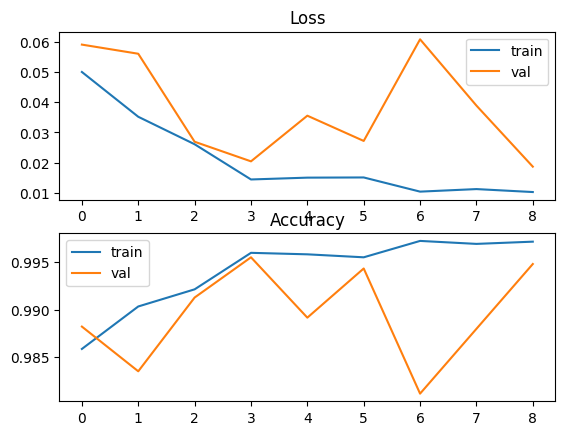

In [31]:
model = get_model((32,32,1))

#train model
opt = keras.optimizers.Adam(learning_rate=.001)

model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=["accuracy"])

#history = model.fit(X_mini, np.array(y_mini), epochs=1, verbose=1)
#history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=32, epochs=2, verbose=2)
#saved_model = model

es = EarlyStopping(monitor='val_accuracy', mode='max', verbose=1, patience=5, min_delta=0.001)
mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=32, epochs=100, callbacks=[es, mc])
#load saved model
saved_model = load_model('best_model.keras')

# evaluate model
_, train_acc = saved_model.evaluate(X_train, y_train, verbose=0)
_, val_acc = saved_model.evaluate(X_val, y_val, verbose=0)
print('Train: %.3f, Validation: %.3f' % (train_acc, val_acc))

# plot loss during training
plt.subplot(211)
plt.title('Loss')
plt.plot(history.history['loss'][1:], label='train')
plt.plot(history.history['val_loss'][1:], label='val')
plt.legend()
# plot accuracy during training
print('')
print('')
plt.subplot(212)
plt.title('Accuracy')
plt.plot(history.history['accuracy'][1:], label='train')
plt.plot(history.history['val_accuracy'][1:], label='val')
plt.legend()
plt.show()

basis lenet: Train: 0.967, Validation: 0.960 
with maxpooling and dropout: Train: 0.998, Validation: 0.996